In [24]:
import re
import json
import numpy as np
import matplotlib.pyplot as plt

In [3]:
parties = ['CDU/CSU', 'GRÜNE','SPD', 'FDP', 'AfD', 'DIE LINKE', 'KPD', 'BP', 'DP', 'WAV', 'Z', 'fraktionslos' ] 

In [5]:
datapath = r'data\test\parsed_2024_example.json'
#datapath = r'data\test\parsed_2022_example.json'
with open(datapath) as f:
    protocol = json.load(f)

In [22]:
party_indices = {party: i for i, party in enumerate(parties)}

aggregated_matrix = np.zeros([len(parties), len(parties)])

for speech in protocol:
    party_speaker = speech['speaker']['party']
    speaker_party_index = party_indices[party_speaker]
    for comment in speech['comments']:
        comment_party = comment['commentator']['party']
        aggregated_matrix[speaker_party_index][party_indices[comment_party]] += 1

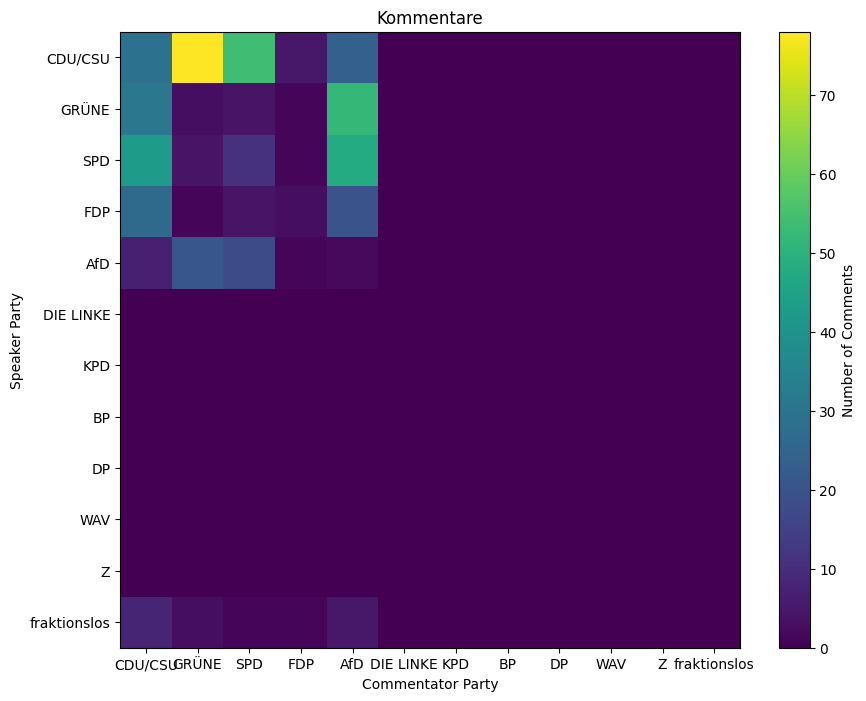

In [27]:
plt.figure(figsize=(10, 8))
plt.imshow(aggregated_matrix, cmap='viridis', aspect='auto')

# labels
plt.xticks(ticks=np.arange(len(parties)), labels=parties)
plt.yticks(ticks=np.arange(len(parties)), labels=parties)
plt.colorbar(label='Number of Comments')
plt.xlabel('Commentator Party')
plt.ylabel('Speaker Party')
plt.title('Kommentare')

plt.show()

In [28]:

num_chars = np.zeros(len(parties))

for speech in protocol:
    party_speaker = speech['speaker']['party']
    num_chars[party_indices[party_speaker]] += len(speech['text'])

In [29]:
num_chars

array([87752., 54703., 86526., 44897., 35639.,     0.,     0.,     0.,
           0.,     0.,     0., 11621.])